# 01 - Limpieza y analisis exploratorio Saber 11

Este notebook carga la base, revisa calidad de datos y genera los principales resumenes del proyecto.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ROOT = Path.cwd().parents[0] if Path.cwd().name == "notebooks" else Path.cwd()
DATA_PATH = ROOT / "data" / "Vista_Resultados_unicos_Saber_11_20260521.csv"
df = pd.read_csv(DATA_PATH, encoding="utf-8")
df.shape

(36613, 51)

Primero cargamos la base de datos Saber 11. La base original tenía 36.613 registros y 51 variables relacionadas con el colegio, el estudiante, la familia y los puntajes.

In [2]:
df.head()

,PERIODO,ESTU_TIPODOCUMENTO,ESTU_CONSECUTIVO,COLE_AREA_UBICACION,COLE_BILINGUE,COLE_CALENDARIO,COLE_CARACTER,COLE_COD_DANE_ESTABLECIMIENTO,COLE_COD_DANE_SEDE,COLE_COD_DEPTO_UBICACION,...,FAMI_TIENECOMPUTADOR,FAMI_TIENEINTERNET,FAMI_TIENELAVADORA,DESEMP_INGLES,PUNT_INGLES,PUNT_MATEMATICAS,PUNT_SOCIALES_CIUDADANAS,PUNT_C_NATURALES,PUNT_LECTURA_CRITICA,PUNT_GLOBAL
0,20132,TI,SB11201320260952,URBANO,N,A,TÉCNICO/ACADÉMICO,115491000017,115491000017,15,...,Si,No,No,A-,43.0,46.0,NaN,NaN,NaN,NaN
1,20162,CC,SB11201620253914,URBANO,N,A,TÉCNICO/ACADÉMICO,115759001887,115759001887,15,...,Si,Si,No,A1,52.0,65.0,56.0,61.0,49.0,287.0
2,20172,TI,SB11201720214776,URBANO,N,A,TÉCNICO/ACADÉMICO,115759000473,115759000473,15,...,Si,Si,Si,A1,57.0,63.0,59.0,54.0,58.0,292.0
3,20152,TI,SB11201520154501,URBANO,N,A,TÉCNICO/ACADÉMICO,115759001615,115759001615,15,...,No,No,Si,A1,57.0,62.0,63.0,57.0,59.0,300.0
4,20162,TI,SB11201620555095,URBANO,N,A,ACADÉMICO,315759001576,315759001576,15,...,Si,Si,Si,A-,37.0,39.0,34.0,35.0,40.0,185.0


Después revisamos las primeras filas para entender qué información contenía la base. Vimos que había variables del colegio, del estudiante, del hogar y los puntajes de las diferentes áreas.

In [3]:
score_cols = [
    "PUNT_INGLES", "PUNT_MATEMATICAS", "PUNT_SOCIALES_CIUDADANAS",
    "PUNT_C_NATURALES", "PUNT_LECTURA_CRITICA", "PUNT_GLOBAL"
]
for col in score_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df[score_cols].describe().round(2)

,PUNT_INGLES,PUNT_MATEMATICAS,PUNT_SOCIALES_CIUDADANAS,PUNT_C_NATURALES,PUNT_LECTURA_CRITICA,PUNT_GLOBAL
count,36613.00,36613.00,23474.00,23474.00,23474.00,23474.00
mean,50.71,53.00,52.41,53.85,54.78,269.95
std,10.63,11.30,10.80,9.34,9.44,44.49
min,-1.00,0.00,0.00,0.00,0.00,0.00
25%,43.00,45.00,45.00,47.00,48.00,238.00
50%,50.00,53.00,53.00,54.00,55.00,269.00
75%,57.00,60.51,60.00,60.00,61.00,301.00
max,117.29,101.00,100.00,100.00,100.00,449.00


Esto convierte las columnas de puntaje a formato numérico.

¿Por qué es importante?

Porque si los puntajes están como texto, no se pueden calcular promedios, medianas, gráficos ni entrenar modelos correctamente.

In [4]:
missing = df.isna().mean().sort_values(ascending=False).mul(100).round(2)
missing.head(15)

PUNT_C_NATURALES            35.89
PUNT_LECTURA_CRITICA        35.89
PUNT_GLOBAL                 35.89
PUNT_SOCIALES_CIUDADANAS    35.89
COLE_BILINGUE                4.19
FAMI_EDUCACIONMADRE          3.72
FAMI_EDUCACIONPADRE          3.70
FAMI_ESTRATOVIVIENDA         2.79
FAMI_TIENECOMPUTADOR         2.64
FAMI_TIENEINTERNET           2.43
FAMI_PERSONASHOGAR           1.59
FAMI_TIENEAUTOMOVIL          1.57
FAMI_CUARTOSHOGAR            1.54
FAMI_TIENELAVADORA           1.53
ESTU_COD_RESIDE_DEPTO        0.64
dtype: float64

Revisamos los valores faltantes y encontramos que el 35.89% de los registros no tenía puntaje global. Por eso esos registros no se usaron para entrenar el modelo, ya que no tenían la variable objetivo.

In [5]:
valid = df.dropna(subset=["PUNT_GLOBAL"]).copy()
valid["puntaje_alto"] = (valid["PUNT_GLOBAL"] >= 300).astype(int)
valid[["PUNT_GLOBAL", "puntaje_alto"]].describe().round(2)

,PUNT_GLOBAL,puntaje_alto
count,23474.00,23474.00
mean,269.95,0.26
std,44.49,0.44
min,0.00,0.00
25%,238.00,0.00
50%,269.00,0.00
75%,301.00,1.00
max,449.00,1.00


Creamos la variable puntaje_alto, que identifica si un estudiante obtuvo 300 puntos o más. Este umbral nos permitió convertir el problema en una clasificación: puntaje alto o no alto.

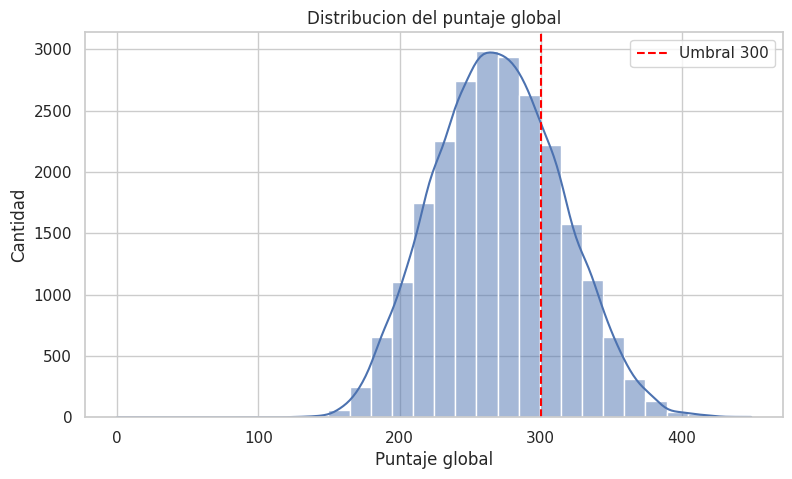

In [6]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(9,5))
sns.histplot(valid["PUNT_GLOBAL"], bins=30, kde=True)
plt.axvline(300, color="red", linestyle="--", label="Umbral 300")
plt.title("Distribucion del puntaje global")
plt.xlabel("Puntaje global")
plt.ylabel("Cantidad")
plt.legend()
plt.show()

Como solo una parte de los estudiantes supera los 300 puntos, el modelo debe aprender a identificar ese grupo específico.

In [7]:
valid.groupby("COLE_NATURALEZA")["PUNT_GLOBAL"].agg(["count", "mean", "median"]).round(2).sort_values("mean", ascending=False)

,count,mean,median
COLE_NATURALEZA,,,
NO OFICIAL,5510,286.25,287.0
OFICIAL,17964,264.95,264.0


In [8]:
valid.groupby("FAMI_TIENEINTERNET")["PUNT_GLOBAL"].agg(["count", "mean", "median"]).round(2).sort_values("mean", ascending=False)

,count,mean,median
FAMI_TIENEINTERNET,,,
Si,11937,281.35,282.0
No,10794,258.37,257.0


También encontramos diferencias según acceso a internet. Los estudiantes que reportan tener internet en el hogar tienen un promedio de puntaje global mayor que quienes no tienen internet.